In [8]:
# 1. Import Dependencies
import pandas as pd
import numpy as np
import random
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
import matplotlib.pyplot as plt

In [9]:
# 2. Data Loading and Preprocessing
# Load the dataset and prepare features and target variable
df = pd.read_csv("extracted_columns.csv")
X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7',
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']

In [10]:
# Perform an 80:20 train-test split with random_state for reproducibility
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
# 3. SVR Hyperparameter Bounds
# Define hyperparameter ranges and kernel options for PSO particle search space
param_bounds = {
    'C': [0.1, 1000],
    'epsilon': [0.01, 1.0],
    'kernel': ['linear', 'rbf']
}
kernel_options = param_bounds['kernel']

In [12]:
# PSO particle creation function
def create_particle():
    # Initialize a particle with random position parameters and zero velocity
    return {
        'position': [
            np.random.uniform(param_bounds['C'][0], param_bounds['C'][1]),  # Continuous: C
            np.random.uniform(param_bounds['epsilon'][0], param_bounds['epsilon'][1]),  # Continuous: epsilon
            np.random.randint(0, len(kernel_options))  # Discrete: kernel as index
        ],
        'velocity': [0, 0, 0],  # Initialize velocity vector for PSO updates
        'best_position': None,
        'best_fitness': -np.inf
    }


In [13]:
# Decode particle position vector to actual SVR hyperparameters
def decode_particle_position(position):
    C = np.clip(position[0], param_bounds['C'][0], param_bounds['C'][1])
    epsilon = np.clip(position[1], param_bounds['epsilon'][0], param_bounds['epsilon'][1])
    kernel_idx = int(np.clip(position[2], 0, len(kernel_options) - 1))
    kernel = kernel_options[kernel_idx]
    return {'C': C, 'epsilon': epsilon, 'kernel': kernel}

# Fitness function using k-fold CV to evaluate RMSE for a given SVR config
def fitness_svr_kfold(individual, X_train, y_train, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = make_pipeline(
            StandardScaler(),
            SVR(C=individual['C'], epsilon=individual['epsilon'], kernel=individual['kernel'])
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val_fold)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, preds)))
    return -np.mean(rmse_scores)  # Negative for maximization in PSO

# PSO hyperparameter optimization over multiple runs and generations
def pso_svr_kfold(X_train, y_train, generations=10, swarm_size=20, runs=30, w=0.7, c1=1.5, c2=1.5, k=5):
    all_results = []
    for run in range(runs):
        print(f"\n=== PSO Run {run+1}/{runs} ===")
        np.random.seed(42 + run)
        random.seed(42 + run)
        swarm = [create_particle() for _ in range(swarm_size)]
        global_best_position = None
        global_best_fitness = -np.inf

        # Initialize fitness for each particle in swarm
        for particle in swarm:
            params = decode_particle_position(particle['position'])
            fitness = fitness_svr_kfold(params, X_train, y_train, k=k)
            particle['best_position'] = particle['position'][:]
            particle['best_fitness'] = fitness
            if fitness > global_best_fitness:
                global_best_fitness = fitness
                global_best_position = particle['position'][:]

        # PSO iterative optimization loop across generations
        for gen in range(generations):
            for particle in swarm:
                for i in range(3):
                    r1, r2 = np.random.rand(), np.random.rand()
                    cognitive = c1 * r1 * (particle['best_position'][i] - particle['position'][i])
                    social = c2 * r2 * (global_best_position[i] - particle['position'][i])
                    particle['velocity'][i] = w * particle['velocity'][i] + cognitive + social
                    particle['position'][i] += particle['velocity'][i]

                # Evaluate updated position fitness
                params = decode_particle_position(particle['position'])
                fitness = fitness_svr_kfold(params, X_train, y_train, k=k)
                if fitness > particle['best_fitness']:
                    particle['best_fitness'] = fitness
                    particle['best_position'] = particle['position'][:]
                if fitness > global_best_fitness:
                    global_best_fitness = fitness
                    global_best_position = particle['position'][:]

            best_params = decode_particle_position(global_best_position)
            print(f"Generation {gen+1}, Best RMSE: {-global_best_fitness:.4f}, Params: {best_params}")

        # Train model on whole training set using best hyperparameters from this run
        best_individual = decode_particle_position(global_best_position)
        final_model = make_pipeline(
            StandardScaler(),
            SVR(C=best_individual['C'], epsilon=best_individual['epsilon'], kernel=best_individual['kernel'])
        )
        final_model.fit(X_train, y_train)
        preds_train = final_model.predict(X_train)

        # Calculate per-run training metrics
        rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
        mae_train = mean_absolute_error(y_train, preds_train)
        r2_train = r2_score(y_train, preds_train)

        print(f"Run {run+1} Metrics -> RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, R^2: {r2_train:.4f}")

        # Append metrics and params for this run
        all_results.append({
            'Run': run+1,
            'C': best_individual['C'],
            'epsilon': best_individual['epsilon'],
            'kernel': best_individual['kernel'],
            'RMSE': rmse_train,
            'MAE': mae_train,
            'R2': r2_train
        })

    # Aggregate and summarize metrics across all runs
    rmse_vals = [res['RMSE'] for res in all_results]
    mae_vals = [res['MAE'] for res in all_results]
    r2_vals = [res['R2'] for res in all_results]

    print("\n=== Final 30-Run PSO Summary ===")
    print(f"Average RMSE: {np.mean(rmse_vals):.4f} ± {np.std(rmse_vals):.4f}")
    print(f"Average MAE: {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")
    print(f"Average R^2: {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")

    # Save results to CSV and plot distributions for visual analysis
    results_df = pd.DataFrame(all_results)
    results_df.to_csv("PSO_SVR_30_Run_Results.csv", index=False)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.boxplot(rmse_vals)
    plt.title("RMSE Distribution")
    plt.ylabel("RMSE")

    plt.subplot(1,3,2)
    plt.boxplot(mae_vals)
    plt.title("MAE Distribution")
    plt.ylabel("MAE")

    plt.subplot(1,3,3)
    plt.boxplot(r2_vals)
    plt.title("R^2 Distribution")
    plt.ylabel("R^2")

    plt.suptitle("PSO-Optimized SVR Performance over Multiple Runs")
    plt.tight_layout()
    plt.show()

    return results_df



=== PSO Run 1/30 ===
Generation 1, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 2, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 3, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 4, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 5, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 6, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 7, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}
Generation 8, Best RMSE: 0.0043, Params: {'C': np.float64(85.73506327474229), 'epsilon': 

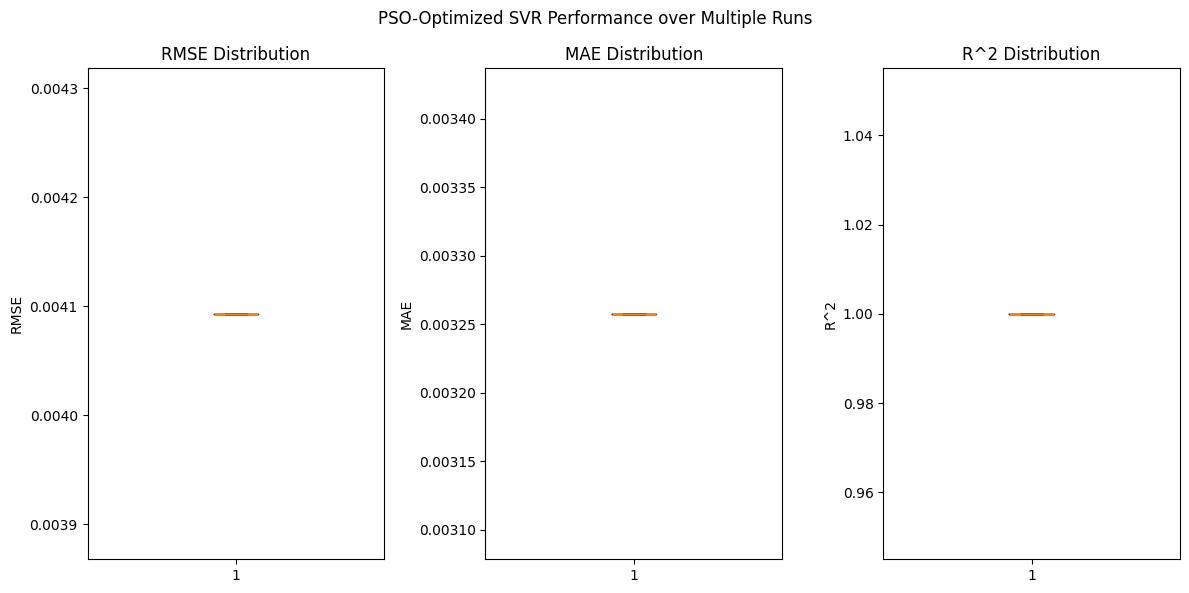

In [14]:
# Run PSO optimization with multiple runs
results_pso = pso_svr_kfold(X_train, y_train, generations=10, swarm_size=20, runs=30)


In [15]:
# Select best run based on lowest RMSE
best_run_pso = results_pso.loc[results_pso['RMSE'].idxmin()]
best_params_pso = {
    'C': best_run_pso['C'],
    'epsilon': best_run_pso['epsilon'],
    'kernel': best_run_pso['kernel']
}
print(f"\nBest hyperparameters from PSO: {best_params_pso}")



Best hyperparameters from PSO: {'C': np.float64(85.73506327474229), 'epsilon': np.float64(0.01), 'kernel': 'linear'}


In [16]:
# Train final model on full training set with best hyperparameters
final_svr_model = make_pipeline(
    StandardScaler(),
    SVR(
        C=best_params_pso['C'],
        epsilon=best_params_pso['epsilon'],
        kernel=best_params_pso['kernel']
    )
)
final_svr_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0


Final PSO-Optimized SVR RMSE: 0.0044
Final PSO-Optimized SVR MAE: 0.0035
Final PSO-Optimized SVR R^2: 1.0000


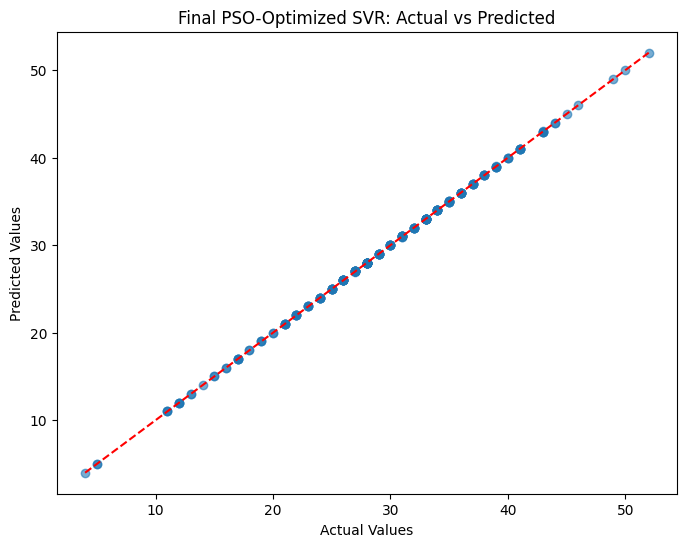

In [17]:
# Evaluate final model on held-out validation set
y_val_pred_pso = final_svr_model.predict(X_val)

def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} RMSE: {rmse:.4f}")
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} R^2: {r2:.4f}")

    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

evaluate_and_plot('Final PSO-Optimized SVR', y_val, y_val_pred_pso)